# 04 - Explicabilidade

Feature maps e Grad-CAM do melhor modelo selecionado pelo conjunto de validacao.

In [1]:
import importlib.util
import os
import subprocess
import sys
from pathlib import Path

IN_COLAB = 'google.colab' in sys.modules

def ensure_package(package, import_name=None):
    import_name = import_name or package.split('==')[0].replace('-', '_')
    if importlib.util.find_spec(import_name) is None:
        subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', package], check=True)

if IN_COLAB:
    ensure_package('medmnist==3.0.2', 'medmnist')
    ensure_package('grad-cam==1.5.2', 'pytorch_grad_cam')
    ensure_package('seaborn', 'seaborn')

project_candidates = [
    Path.cwd(),
    Path.cwd().parent,
    Path('/content/AP2_IA'),
    Path('/content/ap2-ia'),
    Path('/content/drive/MyDrive/AP2_IA'),
    Path('/kaggle/working/ap2-ia'),
    Path('/root/ap2-ia'),
]
PROJECT_ROOT = next((path for path in project_candidates if (path / 'src' / 'train.py').exists()), None)
if PROJECT_ROOT is None:
    raise FileNotFoundError('Nao encontrei a raiz do projeto. No Colab, clone/envie a pasta e execute o notebook dentro dela.')

os.chdir(PROJECT_ROOT)
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

import matplotlib.pyplot as plt
import numpy as np
import torch

from data.dataset import IMAGENET_MEAN, IMAGENET_STD, PATHMNIST_CLASSES, get_loaders
from models.custom_cnn import CustomCNN
from models.transfer import create_model
from utils import device, set_seed
from xai.feature_maps import capture_first_conv_feature_maps, plot_16_feature_maps
from xai.gradcam import gradcam_overlay

set_seed(42)
DEVICE = device()
XAI_DIR = PROJECT_ROOT / 'outputs' / 'xai'
XAI_DIR.mkdir(parents=True, exist_ok=True)
print('Projeto:', PROJECT_ROOT)
print('Dispositivo:', DEVICE)

Projeto: /content/ap2-ia
Dispositivo: cuda


In [2]:
checkpoint_candidates = [
    PROJECT_ROOT / 'checkpoints' / 'final' / 'best_final_model.pt',
    Path('/content/drive/MyDrive/AP2_IA_checkpoints/best_final_model.pt'),
    Path('/kaggle/working/best_final_model.pt'),
]
CHECKPOINT_PATH = next((path for path in checkpoint_candidates if path.exists()), None)
DEFAULT_MODEL = 'resnet50'
DEFAULT_MODE = 'fine_tuning'
BATCH_SIZE = 4

if CHECKPOINT_PATH is None:
    raise FileNotFoundError('Checkpoint final nao encontrado. Coloque best_final_model.pt em checkpoints/final/ ou monte o Drive em /content/drive/MyDrive/AP2_IA_checkpoints/.')

def build_model(name, mode):
    if name == 'custom_cnn':
        return CustomCNN(num_classes=9)
    return create_model(name, num_classes=9, pretrained=False, mode=mode)

checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE)
model_name = checkpoint.get('model', DEFAULT_MODEL)
mode = checkpoint.get('mode', DEFAULT_MODE)

loaders = get_loaders(batch_size=BATCH_SIZE, image_size=224, source_size=224, num_workers=0)
model = build_model(model_name, mode).to(DEVICE)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print('Checkpoint:', CHECKPOINT_PATH)
print('Modelo:', model_name, '| modo:', mode)
print('Classes:', PATHMNIST_CLASSES)

Aviso: checkpoint nao encontrado em /content/ap2-ia/checkpoints/final/best_final_model.pt
Rode o notebook 05 primeiro ou ajuste CHECKPOINT_PATH para um modelo treinado.


100%|██████████| 12.6G/12.6G [15:48<00:00, 13.3MB/s]


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 160MB/s]


Modelo: resnet50 | modo: fine_tuning
Classes: ('adipose', 'background', 'debris', 'lymphocytes', 'mucus', 'smooth muscle', 'normal colon mucosa', 'cancer-associated stroma', 'colorectal adenocarcinoma epithelium')


In [3]:
def denormalize(image_tensor):
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    image = image_tensor.detach().cpu() * std + mean
    return image.clamp(0, 1).permute(1, 2, 0).numpy()

@torch.no_grad()
def collect_examples(loader, max_batches=80):
    correct_high, wrong_high, correct_low = [], [], []
    for batch_idx, (images, labels) in enumerate(loader):
        images = images.to(DEVICE)
        labels = labels.squeeze().long().to(DEVICE)
        probs = torch.softmax(model(images), dim=1)
        confs, preds = probs.max(dim=1)
        for image, label, pred, conf in zip(images.cpu(), labels.cpu(), preds.cpu(), confs.cpu()):
            item = {'image': image, 'label': int(label), 'pred': int(pred), 'conf': float(conf)}
            if pred == label and conf >= 0.90 and len(correct_high) < 5:
                correct_high.append(item)
            elif pred != label and conf >= 0.80 and len(wrong_high) < 5:
                wrong_high.append(item)
            elif pred == label:
                correct_low.append(item)
        if len(correct_high) >= 5 and len(wrong_high) >= 5:
            break
        if batch_idx + 1 >= max_batches:
            break
    background_candidate = sorted(correct_low, key=lambda x: x['conf'])[:1]
    return correct_high, wrong_high, background_candidate

correct_examples, wrong_examples, background_examples = collect_examples(loaders['val'])
print('Acertos confiantes:', len(correct_examples))
print('Erros confiantes:', len(wrong_examples))
print('Candidato para discutir atencao em fundo:', len(background_examples))

Acertos confiantes: 0
Erros confiantes: 0
Candidato para discutir atencao em fundo: 1


Sem exemplos para: 5 predicoes corretas com confianca maior que 0.90
Sem exemplos para: 5 predicoes erradas com confianca maior que 0.80


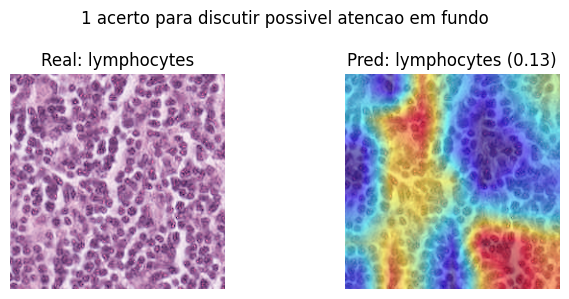

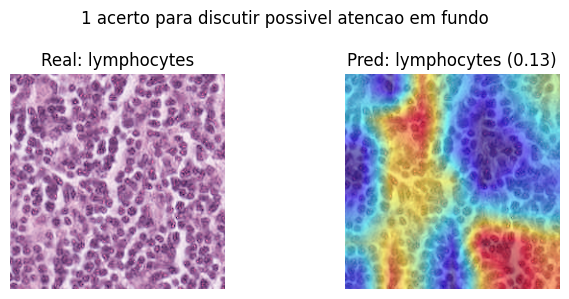

In [4]:
def show_gradcam_grid(examples, title, filename):
    if not examples:
        print('Sem exemplos para:', title)
        return None
    fig, axes = plt.subplots(len(examples), 2, figsize=(7, 3 * len(examples)))
    axes = np.atleast_2d(axes)
    for row, item in enumerate(examples):
        image = item['image']
        rgb = denormalize(image)
        overlay = gradcam_overlay(model, image.unsqueeze(0).to(DEVICE), rgb, target_class=item['pred'])
        label_name = PATHMNIST_CLASSES[item['label']]
        pred_name = PATHMNIST_CLASSES[item['pred']]
        axes[row, 0].imshow(rgb)
        axes[row, 0].set_title(f'Real: {label_name}')
        axes[row, 1].imshow(overlay)
        axes[row, 1].set_title(f'Pred: {pred_name} ({item["conf"]:.2f})')
        for ax in axes[row]:
            ax.axis('off')
    fig.suptitle(title)
    fig.tight_layout()
    fig.savefig(XAI_DIR / filename, dpi=160)
    return fig

show_gradcam_grid(correct_examples, '5 predicoes corretas com confianca maior que 0.90', 'gradcam_correct_high.png')
show_gradcam_grid(wrong_examples, '5 predicoes erradas com confianca maior que 0.80', 'gradcam_wrong_high.png')
show_gradcam_grid(background_examples, '1 acerto para discutir possivel atencao em fundo', 'gradcam_attention_discussion.png')

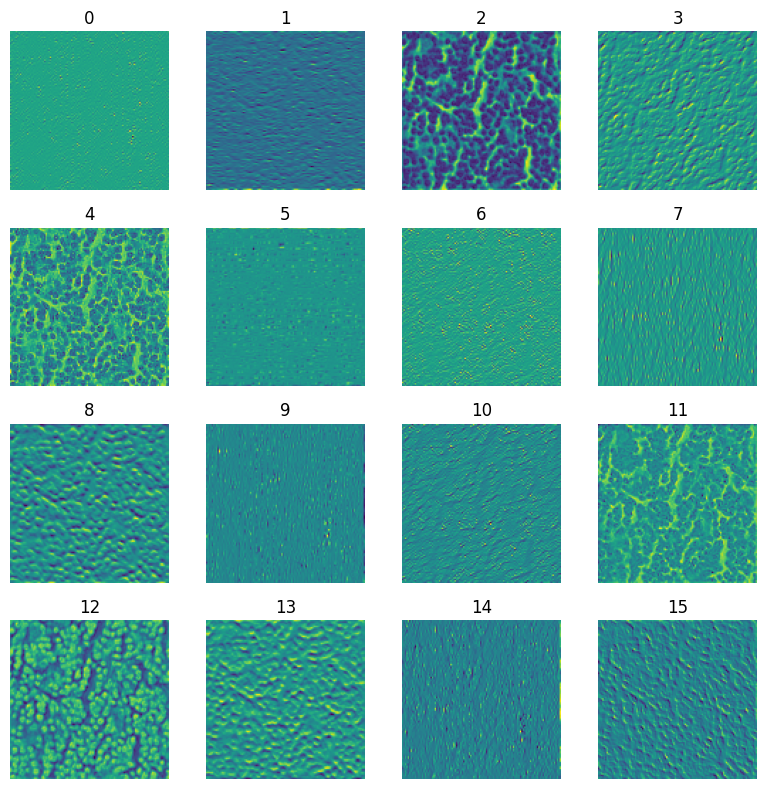

In [5]:
reference_examples = correct_examples or wrong_examples or background_examples
if reference_examples:
    images = torch.stack([item['image'] for item in reference_examples[:4]]).to(DEVICE)
    feature_maps = capture_first_conv_feature_maps(model, images)
    fig = plot_16_feature_maps(feature_maps, image_index=0)
    fig.savefig(XAI_DIR / 'feature_maps_first_conv.png', dpi=160)
else:
    print('Nenhum exemplo foi coletado para feature maps.')

## Discussao

Para cada bloco, descreva se as regioes destacadas pelo Grad-CAM coincidem com estruturas histologicamente relevantes ou se a ativacao ficou concentrada em bordas, fundo, artefatos de preparacao ou padroes pouco interpretaveis. Nos erros confiantes, compare a classe real com a classe prevista e registre uma hipotese visual para a confusao.

Arquivos esperados: `outputs/xai/gradcam_correct_high.png`, `outputs/xai/gradcam_wrong_high.png`, `outputs/xai/gradcam_attention_discussion.png` e `outputs/xai/feature_maps_first_conv.png`.